## Initialize FlorisInterface

The `FlorisInterface` provides functionality to build a wind farm representation and drive
the simulation. This object is created (instantiated) by passing the path to a FLORIS input
file as the only argument. After this object is created, it can immediately be used to
inspect the data.

In [1]:
import numpy as np
from floris.tools import FlorisInterface
import matplotlib.pyplot as plt

Correcting negative Overhang:-2.5
Correcting negative Overhang:-7.5


/opt/miniconda3/envs/whale/lib/python3.10/site-packages/floris/tools/wind_rose.py:1415: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])


<PolarAxesSubplot: >

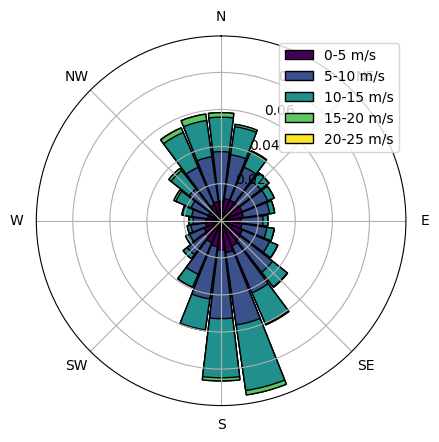

In [2]:
# Copyright 2022 NREL

# Licensed under the Apache License, Version 2.0 (the "License"); you may not
# use this file except in compliance with the License. You may obtain a copy of
# the License at http://www.apache.org/licenses/LICENSE-2.0

# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS, WITHOUT
# WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the
# License for the specific language governing permissions and limitations under
# the License.

# See https://floris.readthedocs.io for documentation


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import NearestNDInterpolator
from floris.tools import FlorisInterface, WindRose, wind_rose

"""
This example demonstrates how to calculate the Annual Energy Production (AEP)
of a wind farm using wind rose information stored in a .csv file.

The wind rose information is first loaded, after which we initialize our Floris
Interface. A 3 turbine farm is generated, and then the turbine wakes and powers
are calculated across all the wind directions. Finally, the farm power is
converted to AEP and reported out.
"""

# Read in the wind rose using the class
wind_rose = WindRose()
wind_rose.read_wind_rose_csv("library/weather/wind_rose.csv")

# Show the wind rose
wind_rose.plot_wind_rose()

## Ocean Wind 1

In [3]:
fi = FlorisInterface("library/project/config/Ocean_Wind_1_gch.yaml") # GCH model
# fi = FlorisInterface("inputs/cc.yaml") # CumulativeCurl model
aep1 = fi.get_farm_AEP_wind_rose_class(
    wind_rose=wind_rose,
    cut_in_wind_speed=3.0,  # Wakes are not evaluated below this wind speed
    cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
)
print("Farm AEP (with cut_in/out specified): {:.3f} GWh".format(aep1 / 1.0e9))

aep_no_wake1 = fi.get_farm_AEP_wind_rose_class(wind_rose=wind_rose, no_wake=True)
print("Farm AEP (no_wake=True): {:.3f} GWh".format(aep_no_wake1 / 1.0e9))



Farm AEP (with cut_in/out specified): 4493.810 GWh
Farm AEP (no_wake=True): 4826.172 GWh


In [4]:
cf1 = 100 * aep1 / 1.0e6/(12*92*8760)
print("Farm c.f. (with cut_in/out specified): {:.2f} %".format(cf1))
cf_no_wake1 = 100 * aep_no_wake1 / 1.0e6/(12*92*8760)
print("Farm c.f. without wake losses: {:.2f} %".format(cf_no_wake1))


Farm c.f. (with cut_in/out specified): 46.47 %
Farm c.f. without wake losses: 49.90 %


## CVOW-C

In [5]:
fi = FlorisInterface("library/project/config/CVOW-C_gch.yaml") # GCH model
# fi = FlorisInterface("inputs/cc.yaml") # CumulativeCurl model
aep2 = fi.get_farm_AEP_wind_rose_class(
    wind_rose=wind_rose,
    cut_in_wind_speed=3.0,  # Wakes are not evaluated below this wind speed
    cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
)
print("Farm AEP (with cut_in/out specified): {:.3f} GWh".format(aep2 / 1.0e9))

aep_no_wake2 = fi.get_farm_AEP_wind_rose_class(wind_rose=wind_rose, no_wake=True)
print("Farm AEP (no_wake=True): {:.3f} GWh".format(aep_no_wake2 / 1.0e9))


Farm AEP (with cut_in/out specified): 10345.411 GWh
Farm AEP (no_wake=True): 11555.075 GWh


In [6]:
cf2 = 100 * aep2 / 1.0e6/(14*189*8760)
print("Farm c.f. (with cut_in/out specified): {:.2f} %".format(cf2))
cf_no_wake2 = 100 * aep_no_wake2 / 1.0e6/(14*189*8760)
print("Farm c.f. without wake losses: {:.2f} %".format(cf_no_wake2))


Farm c.f. (with cut_in/out specified): 44.63 %
Farm c.f. without wake losses: 49.85 %
